In [1]:
import math
import random
import glob
import pathlib
import itertools
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as f
import librosa
import jams
from scipy.signal import butter, sosfilt
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

In [2]:
sr = 16000
hop = 160
hop_time = hop / sr
win_frames = 64
fmin = 32.7
n_bins = 120
bins_per_octave = 24
fmax = fmin * (2 ** (n_bins / bins_per_octave))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base = pathlib.Path("data/raw")

cqt_freqs = fmin * (2 ** (np.arange(n_bins) / bins_per_octave))
print(f"Device: {device} | Bins: {n_bins} | Range: {cqt_freqs[0]:.1f} - {cqt_freqs[-1]:.1f} Hz")


Device: cuda | Bins: 120 | Range: 32.7 - 1016.6 Hz


In [3]:
def hz_to_cents(hz):
    return 1200 * np.log2(hz / 32.7)


def cents_to_hz(c):
    return 32.7 * (2 ** (c / 1200))


def hz_to_bin(hz):
    if hz <= 0:
        return n_bins
    cents = hz_to_cents(hz)
    return int(np.clip(round(cents / (1200 / bins_per_octave)), 0, n_bins - 1))


def bin_to_hz(b):
    return float(cqt_freqs[int(b)])


def hz_to_midi(hz):
    return 69 + 12 * math.log2(hz / 440.0)


def midi_to_hz(m):
    return 440.0 * (2 ** ((m - 69) / 12))


def cents_err(a, b):
    if a > 0 and b > 0:
        return 1200 * abs(math.log2(a / b))
    return 1e9


In [4]:
def compute_cqt(y):
    cqt = librosa.cqt(
        y, sr=sr, hop_length=hop, fmin=fmin,
        n_bins=n_bins, bins_per_octave=bins_per_octave
    )
    mag = np.abs(cqt).astype(np.float32)
    mag = np.log1p(mag)
    return mag


In [5]:
def jams_to_frames(jam_path, wav_path, aug=False):
    jam = jams.load(str(jam_path))
    y, _ = librosa.load(str(wav_path), sr=sr, mono=True)

    if aug and random.random() < 0.2:
        cutoff = random.uniform(3000, 7000)
        sos = butter(2, cutoff, btype="low", fs=sr, output="sos")
        y = sosfilt(sos, y).astype(np.float32)

    cqt = compute_cqt(y)
    n_frames = cqt.shape[1]

    anns = [a for a in jam.annotations if a.namespace == "pitch_contour"]
    times = []
    freqs = []
    for ann in anns:
        for obs in ann.data:
            t = float(obs.time)
            d = obs.value
            f0 = float(d.get("frequency", d.get("value", 0)))
            voiced = bool(d.get("voiced", f0 > 0))
            if voiced and f0 > 0 and f0 >= fmin and f0 <= fmax:
                times.append(t)
                freqs.append(f0)

    if len(times) == 0:
        return [], []

    times = np.array(times, dtype=np.float32)
    freqs = np.array(freqs, dtype=np.float32)
    order = np.argsort(times)
    times = times[order]
    freqs = freqs[order]

    out_y = []
    out_b = []
    prev_gt = 0

    for i in range(n_frames):
        tp = (i * hop) / sr
        cand = np.where(np.abs(times - tp) <= 0.03)[0]

        if len(cand) == 0:
            gt = 0
        elif len(cand) == 1:
            gt = float(freqs[cand[0]])
        else:
            cand_freqs = freqs[cand]
            cand_times = times[cand]
            dists = np.abs(cand_times - tp)
            best = int(np.argmin(dists))
            if np.sum(dists == dists[best]) > 1:
                tie = np.where(dists == dists[best])[0]
                if prev_gt > 0:
                    tie_freqs = cand_freqs[tie]
                    diffs = np.abs(hz_to_cents(tie_freqs) - hz_to_cents(prev_gt))
                    best = int(tie[np.argmin(diffs)])
                else:
                    best = int(tie[len(tie) // 2])
            gt = float(cand_freqs[best])

        if gt > 0:
            prev_gt = gt

        feat = cqt[:, i]
        if gt <= 0:
            b = n_bins
        else:
            b = hz_to_bin(gt)

        out_y.append(feat)
        out_b.append(b)

    return out_y, out_b


In [6]:
def mir1k_to_frames(wav_path, pv_path, aug=False):
    y, sr_m = librosa.load(str(wav_path), sr=sr, mono=False)
    if y.ndim == 2:
        y = y[1] if y.shape[0] > 1 else y[0]
    y = y.astype(np.float32)

    if aug and random.random() < 0.2:
        cutoff = random.uniform(3000, 7000)
        sos = butter(2, cutoff, btype="low", fs=sr, output="sos")
        y = sosfilt(sos, y).astype(np.float32)

    cqt = compute_cqt(y)
    n_frames = cqt.shape[1]

    vals = []
    with open(str(pv_path), "r") as fh:
        for line in fh:
            line = line.strip()
            if line == "":
                vals.append(0.0)
                continue
            v = line.split()[0]
            vals.append(float(v) if v.replace(".", "", 1).lstrip("-").isdigit() else 0.0)

    vals = np.array(vals, dtype=np.float32)

    out_y = []
    out_b = []

    for i in range(n_frames):
        tp = (i * hop) / sr
        j = int(round(tp / 0.02))

        if j < 0 or j >= len(vals):
            gt = 0
        else:
            semi = float(vals[j])
            if semi <= 0:
                gt = 0
            else:
                gt = float(midi_to_hz(semi))

        feat = cqt[:, i]
        if gt <= 0 or gt < fmin or gt > fmax:
            b = n_bins
        else:
            b = hz_to_bin(gt)

        out_y.append(feat)
        out_b.append(b)

    return out_y, out_b


In [7]:
def collect():
    jam_files = sorted(glob.glob(str(base / "guitarset/annotation/*_solo.jams")))
    mir_wavs = sorted(glob.glob(str(base / "mir1k/Wavfile/*.wav")))

    guitar_items = []
    for jf in jam_files:
        name = pathlib.Path(jf).stem
        wav = base / f"guitarset/audio_mono_mic/{name}_mic.wav"
        if not wav.exists():
            wav = base / f"guitarset/audio_mono_mic/{name}.wav"
        if wav.exists():
            guitar_items.append((str(wav), str(jf)))

    mir_items = []
    for w in mir_wavs:
        pv = base / f"mir1k/PitchLabel/{pathlib.Path(w).stem}.pv"
        if pv.exists():
            mir_items.append((str(w), str(pv)))

    print(f"Guitarset: {len(guitar_items)} | Mir1k: {len(mir_items)}")
    return guitar_items, mir_items


def build_splits(guitar_items, mir_items):
    g_train = []
    g_val = []
    g_test = []
    for w, j in guitar_items:
        pid = pathlib.Path(j).name[:2]
        if pid in ["00", "01", "02", "03"]:
            g_train.append((w, j))
        elif pid == "04":
            g_val.append((w, j))
        elif pid == "05":
            g_test.append((w, j))

    singers = sorted(set(pathlib.Path(w).stem.split("_")[0] for w, _ in mir_items))
    train_singers = set(singers[:13])
    val_singers = set(singers[13:16])
    test_singers = set(singers[16:])

    m_train = []
    m_val = []
    m_test = []
    for w, pv in mir_items:
        sid = pathlib.Path(w).stem.split("_")[0]
        if sid in train_singers:
            m_train.append((w, pv))
        elif sid in val_singers:
            m_val.append((w, pv))
        elif sid in test_singers:
            m_test.append((w, pv))

    print(f"Guitarset - Train: {len(g_train)} | Val: {len(g_val)} | Test: {len(g_test)}")
    print(f"Mir1k - Train: {len(m_train)} | Val: {len(m_val)} | Test: {len(m_test)}")
    return (g_train, g_val, g_test), (m_train, m_val, m_test)


guitar_items, mir_items = collect()
g_split, m_split = build_splits(guitar_items, mir_items)


Guitarset: 180 | Mir1k: 1000
Guitarset - Train: 120 | Val: 30 | Test: 30
Mir1k - Train: 696 | Val: 186 | Test: 118


In [10]:
class AudioDataset(torch.utils.data.Dataset):
    def __init__(self, g_list, m_list, aug=True):
        self.aug = aug
        self.clips = []
        self.index = []

        print("Caching guitarset...")
        for w, j in g_list:
            ys, bs = jams_to_frames(j, w, aug=self.aug)
            if len(ys) == 0:
                continue
            ci = len(self.clips)
            self.clips.append((np.stack(ys), np.array(bs, dtype=np.int64)))
            for fi in range(len(ys)):
                self.index.append((ci, fi))

        print("Caching mir1k...")
        for w, pv in m_list:
            ys, bs = mir1k_to_frames(w, pv, aug=self.aug)
            if len(ys) == 0:
                continue
            ci = len(self.clips)
            self.clips.append((np.stack(ys), np.array(bs, dtype=np.int64)))
            for fi in range(len(ys)):
                self.index.append((ci, fi))

        print(f"Clips: {len(self.clips):,} | Frames: {len(self.index):,}")
        random.shuffle(self.index)

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        ci, fi = self.index[idx]
        feats, labels = self.clips[ci]
        half = win_frames // 2
        s = fi - half
        e = s + win_frames
        pl = max(0, -s)
        pr = max(0, e - len(feats))
        cs = max(0, s)
        ce = min(len(feats), e)

        w = feats[cs:ce].copy()
        if pl > 0:
            w = np.concatenate([np.zeros((pl, 120), dtype=np.float32), w])
        if pr > 0:
            w = np.concatenate([w, np.zeros((pr, 120), dtype=np.float32)])

        if self.aug:
            if random.random() < 0.3:
                w = w * random.uniform(0.5, 1.5)
            if random.random() < 0.4:
                w = w + np.random.randn(*w.shape).astype(np.float32) * 0.01
            if random.random() < 0.3:
                f0 = random.randint(0, max(0, 120 - 8))
                w[:, f0:f0+8] = 0
            if random.random() < 0.3:
                t0 = random.randint(0, max(0, win_frames - 4))
                w[t0:t0+4] = 0

        return torch.from_numpy(w.T), torch.tensor(int(labels[fi]), dtype=torch.long)


train_set = AudioDataset(g_split[0], m_split[0], aug=True)
val_set = AudioDataset(g_split[1], m_split[1], aug=False)
test_set = AudioDataset(g_split[2], m_split[2], aug=False)
print(f"Train: {len(train_set):,} | Val: {len(val_set):,} | Test: {len(test_set):,}")


Caching guitarset...
Caching mir1k...
Clips: 816 | Frames: 928,190
Caching guitarset...
Caching mir1k...
Clips: 216 | Frames: 242,648
Caching guitarset...
Caching mir1k...
Clips: 148 | Frames: 178,822
Train: 928,190 | Val: 242,648 | Test: 178,822


In [11]:
class MusicModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv1d(120, 64, 8, stride=2, padding=4)
        self.b1 = nn.BatchNorm1d(64)
        self.c2 = nn.Conv1d(64, 128, 8, stride=2, padding=4)
        self.b2 = nn.BatchNorm1d(128)
        self.c3 = nn.Conv1d(128, 256, 8, stride=2, padding=4)
        self.b3 = nn.BatchNorm1d(256)
        self.c4 = nn.Conv1d(256, 256, 4, stride=2, padding=2)
        self.b4 = nn.BatchNorm1d(256)
        self.fc1 = nn.Linear(256, 256)
        self.fc2 = nn.Linear(256, n_bins + 1)
        self.drop = nn.Dropout(0.5)

    def forward(self, x):
        x = f.relu(self.b1(self.c1(x)))
        x = f.relu(self.b2(self.c2(x)))
        x = f.relu(self.b3(self.c3(x)))
        x = f.relu(self.b4(self.c4(x)))
        x = x.mean(dim=2)
        x = self.drop(f.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


model = MusicModel().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


Model parameters: 750,265


In [13]:
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=128, shuffle=True, num_workers=4
)
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=256, shuffle=False, num_workers=4
)
test_loader = torch.utils.data.DataLoader(
    test_set, batch_size=256, shuffle=False, num_workers=4
)

opt = torch.optim.Adam(model.parameters(), lr=3e-5, weight_decay=1e-3)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)
crit = nn.CrossEntropyLoss(label_smoothing=0.03)
best = 1e9
patience = 10
wait = 0
epochs = 150

for ep in range(epochs):
    model.train()
    tot = 0
    tot_l = 0

    for y, b in train_loader:
        y = y.to(device)
        b = b.to(device)
        opt.zero_grad()
        out = model(y)
        loss = crit(out, b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 3.0)
        opt.step()
        tot_l += loss.item() * y.size(0)
        tot += y.size(0)

    model.eval()
    vtot = 0
    vl = 0
    vacc = 0

    with torch.no_grad():
        for y, b in val_loader:
            y = y.to(device)
            b = b.to(device)
            out = model(y)
            loss = crit(out, b)
            vl += loss.item() * y.size(0)
            pred = out.argmax(dim=1)
            vacc += (pred == b).float().sum().item()
            vtot += y.size(0)

    vl /= max(vtot, 1)
    vacc /= max(vtot, 1)
    sched.step(vl)
    lr_now = opt.param_groups[0]["lr"]
    print(f"Epoch {ep+1:02d}/{epochs} | Train Loss {tot_l/max(tot,1):.4f} | Val Loss {vl:.4f} | Acc {vacc:.3f} | LR {lr_now:.2e}")

    if vl < best - 1e-4:
        best = vl
        wait = 0
        torch.save({"model": model.state_dict(), "ep": ep, "loss": vl}, "music.pt")
        print("Saved model.")
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {ep+1}.")
            break


Epoch 01/150 | Train Loss 1.0834 | Val Loss 0.9924 | Acc 0.775 | LR 3.00e-05
Saved model.
Epoch 02/150 | Train Loss 1.0013 | Val Loss 0.9522 | Acc 0.786 | LR 3.00e-05
Saved model.
Epoch 03/150 | Train Loss 0.9620 | Val Loss 0.9315 | Acc 0.791 | LR 3.00e-05
Saved model.
Epoch 04/150 | Train Loss 0.9356 | Val Loss 0.9179 | Acc 0.797 | LR 3.00e-05
Saved model.
Epoch 05/150 | Train Loss 0.9180 | Val Loss 0.9106 | Acc 0.799 | LR 3.00e-05
Saved model.
Epoch 06/150 | Train Loss 0.9032 | Val Loss 0.9189 | Acc 0.798 | LR 3.00e-05
Epoch 07/150 | Train Loss 0.8935 | Val Loss 0.9076 | Acc 0.801 | LR 3.00e-05
Saved model.
Epoch 08/150 | Train Loss 0.8840 | Val Loss 0.9048 | Acc 0.801 | LR 3.00e-05
Saved model.
Epoch 09/150 | Train Loss 0.8768 | Val Loss 0.9035 | Acc 0.802 | LR 3.00e-05
Saved model.
Epoch 10/150 | Train Loss 0.8692 | Val Loss 0.8993 | Acc 0.803 | LR 3.00e-05
Saved model.
Epoch 11/150 | Train Loss 0.8644 | Val Loss 0.9015 | Acc 0.803 | LR 3.00e-05
Epoch 12/150 | Train Loss 0.8584 | V

In [18]:
ckpt_file = pathlib.Path("music.pt")
if ckpt_file.exists():
    sd = torch.load(str(ckpt_file), map_location=device)
    model.load_state_dict(sd["model"])

model.eval()


def predict_frames(y):
    cqt = compute_cqt(y)
    n_frames = cqt.shape[1]
    out_hz = np.zeros(n_frames, dtype=np.float32)
    out_conf = np.zeros(n_frames, dtype=np.float32)
    out_bin = np.zeros(n_frames, dtype=np.int32)
    bs = 256
    half = win_frames // 2

    with torch.no_grad():
        for s in range(0, n_frames, bs):
            e = min(s + bs, n_frames)
            windows = []
            for i in range(s, e):
                ws = i - half
                we = ws + win_frames
                pl = max(0, -ws)
                pr = max(0, we - n_frames)
                cs = max(0, ws)
                ce = min(n_frames, we)
                w = cqt[:, cs:ce].T
                if pl > 0:
                    w = np.concatenate([np.zeros((pl, 120), dtype=np.float32), w])
                if pr > 0:
                    w = np.concatenate([w, np.zeros((pr, 120), dtype=np.float32)])
                windows.append(w)

            batch = np.stack(windows)
            batch = torch.from_numpy(batch.transpose(0, 2, 1)).to(device)
            prob = torch.softmax(model(batch), dim=1).cpu().numpy()
            pred_bin = prob.argmax(axis=1)

            for j, pb in enumerate(pred_bin):
                idx = s + j
                if pb >= n_bins:
                    out_hz[idx] = 0
                    out_conf[idx] = float(prob[j, pb])
                    out_bin[idx] = n_bins
                else:
                    lo = max(0, int(pb) - 2)
                    hi = min(n_bins - 1, int(pb) + 2)
                    wprob = prob[j, lo : hi + 1]
                    bidx = np.arange(lo, hi + 1)
                    out_hz[idx] = float(np.sum(wprob * cqt_freqs[bidx]) / (np.sum(wprob) + 1e-9))
                    out_conf[idx] = float(prob[j, pb])
                    out_bin[idx] = int(pb)

    times = np.arange(n_frames, dtype=np.float32) * hop_time
    return times, out_hz, out_conf, out_bin


def load_audio(path, sr_in):
    y, _ = librosa.load(str(path), sr=sr_in, mono=True)
    return y.astype(np.float32)


def eval_loader(loader, label):
    tot = 0
    ok50 = 0
    ok25 = 0
    vo = 0
    vt = 0
    fp = 0

    with torch.no_grad():
        for y, b in loader:
            y = y.to(device)
            b = b.to(device)
            prob = torch.softmax(model(y), dim=1).cpu().numpy()
            pred = prob.argmax(axis=1)
            gt = b.cpu().numpy()

            for i in range(len(gt)):
                g = int(gt[i])
                p = int(pred[i])

                if g < n_bins:
                    vt += 1
                if g < n_bins and p < n_bins:
                    vo += 1
                if g >= n_bins and p < n_bins:
                    fp += 1
                if g >= n_bins:
                    continue
                if p >= n_bins:
                    tot += 1
                    continue

                lo = max(0, p - 2)
                hi = min(n_bins - 1, p + 2)
                wprob = prob[i, lo : hi + 1]
                bidx = np.arange(lo, hi + 1)
                phz = float(np.sum(wprob * cqt_freqs[bidx]) / (np.sum(wprob) + 1e-9))
                ghz = float(bin_to_hz(g))

                ce = cents_err(phz, ghz)
                tot += 1
                ok50 += int(ce < 50)
                ok25 += int(ce < 25)

                if tot >= 8000:
                    break

            if tot >= 8000:
                break

    recall = vo / max(vt, 1)
    prec = vo / max(vo + fp, 1)
    vf1 = 2 * prec * recall / max(prec + recall, 1e-9)
    print(f"{label} | RPA50 {ok50/max(tot,1):.3f} | RPA25 {ok25/max(tot,1):.3f} | Voicing F1 {vf1:.3f} | Recall {recall:.3f} | N {tot}")


eval_loader(val_loader, "val")
eval_loader(test_loader, "test")


val | RPA50 0.893 | RPA25 0.774 | Voicing F1 0.955 | Recall 0.947 | N 8000
test | RPA50 0.911 | RPA25 0.822 | Voicing F1 0.955 | Recall 0.963 | N 8000


In [19]:
all_gt = []
all_prob = []

with torch.no_grad():
    for y, b in val_loader:
        y = y.to(device)
        all_gt.extend((b < n_bins).numpy().tolist())
        all_prob.append(torch.softmax(model(y), dim=1).cpu().numpy())

all_gt = np.array(all_gt[:5000])
all_prob = np.concatenate(all_prob, axis=0)[:5000]
pred_bin = all_prob.argmax(axis=1)
pred_conf = all_prob[np.arange(len(pred_bin)), pred_bin]

th_vals = np.arange(0.05, 0.55, 0.02).tolist()
best_f1 = -1
best_th = 0.30

for th in th_vals:
    pred_voiced = (pred_bin < n_bins) & (pred_conf >= th)
    f1 = f1_score(all_gt.astype(int), pred_voiced.astype(int), zero_division=0)
    print(f"Threshold {th:.2f} | F1 {f1:.3f}")
    if f1 > best_f1:
        best_f1 = f1
        best_th = th

print(f"Chosen threshold {best_th} | F1 {best_f1:.3f}")
conf_th_calib = best_th


Threshold 0.05 | F1 0.953
Threshold 0.07 | F1 0.953
Threshold 0.09 | F1 0.952
Threshold 0.11 | F1 0.952
Threshold 0.13 | F1 0.951
Threshold 0.15 | F1 0.951
Threshold 0.17 | F1 0.950
Threshold 0.19 | F1 0.949
Threshold 0.21 | F1 0.948
Threshold 0.23 | F1 0.945
Threshold 0.25 | F1 0.943
Threshold 0.27 | F1 0.940
Threshold 0.29 | F1 0.938
Threshold 0.31 | F1 0.935
Threshold 0.33 | F1 0.933
Threshold 0.35 | F1 0.929
Threshold 0.37 | F1 0.925
Threshold 0.39 | F1 0.920
Threshold 0.41 | F1 0.916
Threshold 0.43 | F1 0.912
Threshold 0.45 | F1 0.905
Threshold 0.47 | F1 0.899
Threshold 0.49 | F1 0.889
Threshold 0.51 | F1 0.879
Threshold 0.53 | F1 0.869
Chosen threshold 0.05 | F1 0.953


In [20]:
def detect_onsets(y, sr_in):
    o = librosa.onset.onset_strength(y=y, sr=sr_in, hop_length=hop)
    t = librosa.onset.onset_detect(
        onset_envelope=o, sr=sr_in, hop_length=hop, units="time"
    )
    return np.array(t, dtype=np.float32)


def estimate_tempo(y, sr_in):
    o = librosa.onset.onset_strength(y=y, sr=sr_in, hop_length=hop)
    t = librosa.feature.tempo(onset_envelope=o, sr=sr_in, hop_length=hop)
    return float(t[0]) if len(t) > 0 else 0.0


def dtw_align(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros(0), np.zeros(0)
    _, wp = librosa.sequence.dtw(
        X=a.reshape(1, -1), Y=b.reshape(1, -1), metric="euclidean"
    )
    wp = np.array(wp)[::-1]
    return wp[:, 0], wp[:, 1]


In [21]:
groups = defaultdict(list)
for w, j in g_split[0]:
    k = pathlib.Path(j).stem.split("_")[1]
    groups[k].append(w)

piece_of = {}
for w, j in g_split[0]:
    piece_of[w] = pathlib.Path(j).stem.split("_")[1]

pos_pairs = []
for wavs in groups.values():
    if len(wavs) >= 2:
        pos_pairs.extend(list(itertools.combinations(wavs[:3], 2)))

all_wavs = [w for w, _ in g_split[0]] + [w for w, _ in m_split[0]]
neg_pairs = []
for _ in range(len(pos_pairs)):
    for _attempt in range(100):
        a, b = random.sample(all_wavs, 2)
        pa = piece_of.get(a, "")
        pb = piece_of.get(b, "")
        if pa == "" or pb == "" or pa != pb:
            neg_pairs.append((a, b))
            break

print(f"Gate pairs - Pos: {len(pos_pairs)} | Neg: {len(neg_pairs)}")

all_pairs = pos_pairs + neg_pairs
pair_feats = {}
for a, b in set(all_pairs):
    for p in [a, b]:
        if p not in pair_feats:
            y = load_audio(p, sr)
            pair_feats[p] = (len(detect_onsets(y, sr)), estimate_tempo(y, sr))

best_f1_gate = -1
best_tempo = 6
best_ratio = 0.85

for tempo_tol in [2, 4, 6, 8, 10, 14, 18]:
    for ratio_tol in [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
        tp = fp = fn = tn = 0

        for a, b in pos_pairs:
            n1, t1 = pair_feats[a]
            n2, t2 = pair_feats[b]
            diff = abs(t1 - t2)
            ratio = min(n1, n2) / max(max(n1, n2), 1)
            rel = (diff <= tempo_tol) and (ratio >= ratio_tol)
            if rel:
                tp += 1
            else:
                fn += 1

        for a, b in neg_pairs:
            n1, t1 = pair_feats[a]
            n2, t2 = pair_feats[b]
            diff = abs(t1 - t2)
            ratio = min(n1, n2) / max(max(n1, n2), 1)
            rel = (diff <= tempo_tol) and (ratio >= ratio_tol)
            if not rel:
                tn += 1
            else:
                fp += 1

        prec = tp / max(tp + fp, 1)
        rec = tp / max(tp + fn, 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-9)
        print(f"Tempo {tempo_tol} | Ratio {ratio_tol:.2f} | F1 {f1:.3f}")
        if f1 > best_f1_gate:
            best_f1_gate = f1
            best_tempo = tempo_tol
            best_ratio = ratio_tol

print(f"Chosen gate - Tempo {best_tempo} | Ratio {best_ratio} | F1 {best_f1_gate:.3f}")
tempo_tol_calib = best_tempo
onset_ratio_calib = best_ratio


Gate pairs - Pos: 90 | Neg: 90
Tempo 2 | Ratio 0.60 | F1 0.492
Tempo 2 | Ratio 0.65 | F1 0.467
Tempo 2 | Ratio 0.70 | F1 0.427
Tempo 2 | Ratio 0.75 | F1 0.386
Tempo 2 | Ratio 0.80 | F1 0.296
Tempo 2 | Ratio 0.85 | F1 0.283
Tempo 2 | Ratio 0.90 | F1 0.198
Tempo 4 | Ratio 0.60 | F1 0.623
Tempo 4 | Ratio 0.65 | F1 0.582
Tempo 4 | Ratio 0.70 | F1 0.531
Tempo 4 | Ratio 0.75 | F1 0.484
Tempo 4 | Ratio 0.80 | F1 0.397
Tempo 4 | Ratio 0.85 | F1 0.315
Tempo 4 | Ratio 0.90 | F1 0.233
Tempo 6 | Ratio 0.60 | F1 0.652
Tempo 6 | Ratio 0.65 | F1 0.613
Tempo 6 | Ratio 0.70 | F1 0.565
Tempo 6 | Ratio 0.75 | F1 0.520
Tempo 6 | Ratio 0.80 | F1 0.424
Tempo 6 | Ratio 0.85 | F1 0.330
Tempo 6 | Ratio 0.90 | F1 0.233
Tempo 8 | Ratio 0.60 | F1 0.653
Tempo 8 | Ratio 0.65 | F1 0.614
Tempo 8 | Ratio 0.70 | F1 0.567
Tempo 8 | Ratio 0.75 | F1 0.523
Tempo 8 | Ratio 0.80 | F1 0.433
Tempo 8 | Ratio 0.85 | F1 0.342
Tempo 8 | Ratio 0.90 | F1 0.248
Tempo 10 | Ratio 0.60 | F1 0.653
Tempo 10 | Ratio 0.65 | F1 0.615
Tempo 1

In [22]:
def practice_report(ref_path, rec_path, conf_th=conf_th_calib, tempo_tol=tempo_tol_calib, ratio_tol=onset_ratio_calib):

    y_ref = load_audio(ref_path, sr)
    y_rec = load_audio(rec_path, sr)

    tr, hr, cr, _ = predict_frames(y_ref)
    tp, hp, cp, _ = predict_frames(y_rec)

    on_ref = detect_onsets(y_ref, sr)
    on_rec = detect_onsets(y_rec, sr)
    tempo_ref = estimate_tempo(y_ref, sr)
    tempo_rec = estimate_tempo(y_rec, sr)

    chroma_ref = librosa.feature.chroma_cqt(y=y_ref, sr=sr, hop_length=hop)
    chroma_rec = librosa.feature.chroma_cqt(y=y_rec, sr=sr, hop_length=hop)

    cents = []
    n_tune = 0
    vo = 0

    if chroma_ref.shape[1] > 0 and chroma_rec.shape[1] > 0:
        _, wp = librosa.sequence.dtw(
            X=chroma_ref, Y=chroma_rec, metric="euclidean"
        )
        wp = np.array(wp)[::-1]

        for r, c_ in wp:
            if r >= len(hr) or c_ >= len(hp):
                continue
            gr = float(hr[int(r)])
            pr = float(hp[int(c_)])
            if gr < fmin or pr < fmin:
                continue
            if cr[int(r)] < conf_th or cp[int(c_)] < conf_th:
                continue
            vo += 1
            ce = cents_err(pr, gr)
            cents.append(ce)

    if cents:
        octave_list = [min(v % 1200, 1200 - v % 1200) for v in cents]
        octave_acc = float(sum(1 for v in octave_list if v < 50) / max(len(octave_list), 1))
    else:
        octave_list = []
        octave_acc = 0.0

    for ce in cents:
        n_tune += int(ce < 50)

    pitch_acc = n_tune / max(vo, 1)

    octave_score = int(round(octave_acc * 100))
    median_octave = float(np.median(octave_list)) if octave_list else 0.0
    median_cents = float(np.median(cents)) if cents else 0.0
    mean_cents = float(np.mean(cents)) if cents else 0.0

    err = []
    if len(on_ref) > 0 and len(on_rec) > 0:
        on_ref_n = on_ref - on_ref[0]
        on_rec_n = on_rec - on_rec[0]
        ii, jj = dtw_align(on_ref_n, on_rec_n)
        for k in range(len(ii)):
            ref_t = float(on_ref_n[int(ii[k])])
            rec_t = float(on_rec_n[int(jj[k])])
            err.append(abs(ref_t - rec_t) * 1000)

    median_onset = float(np.median(err)) if err else 0.0
    mean_onset = float(np.mean(err)) if err else 0.0
    on_acc = float(np.mean(np.array(err) < 70)) if err else 0.0

    pitch_score = int(round(pitch_acc * 100))
    time_score = int(round(on_acc * 100))

    tempo_diff = abs(tempo_ref - tempo_rec) if tempo_ref > 0 else 0.0
    onset_ratio = min(len(on_ref), len(on_rec)) / max(
        max(len(on_ref), len(on_rec)), 1
    )
    reliable = (tempo_diff <= tempo_tol) and (onset_ratio >= ratio_tol)
    time_rep = time_score if reliable else time_score // 2

    overall = int(round(0.3 * pitch_score + 0.3 * octave_score + 0.4 * time_rep))

    issues = []
    if octave_acc < 0.75:
        issues.append(f"Octave low: {octave_score}/100 | Median: {median_octave:.0f} cents")
    elif pitch_acc < 0.75:
        issues.append(f"Pitch low: {pitch_score}/100 | Octave: {octave_score}/100 | Median: {median_cents:.0f} cents")
    elif median_cents > 30:
        issues.append(f"Tuning drift: {median_cents:.0f} cents")
    else:
        issues.append("Pitch solid")

    if not reliable:
        issues.append(f"Timing unreliable: tempo {tempo_ref:.0f} vs {tempo_rec:.0f} bpm | onset {len(on_ref)} vs {len(on_rec)}")
    elif on_acc < 0.7:
        issues.append(f"Timing off: median {median_onset:.0f} ms")
    else:
        issues.append("Timing solid")

    if tempo_diff > tempo_tol and tempo_ref > 0:
        issues.append(f"Tempo mismatch: ref {tempo_ref:.0f} vs rec {tempo_rec:.0f} bpm")

    rep = {
        "Pitch Score": pitch_score,
        "Octave Score": octave_score,
        "Timing Score": time_rep,
        "Timing Reliable": reliable,
        "Overall": overall,
        "Median Cents": median_cents,
        "Median Octave": median_octave,
        "Mean Cents": mean_cents,
        "Median Onset (ms)": median_onset,
        "Mean Onset (ms)": mean_onset,
        "Tempo Ref": tempo_ref,
        "Tempo Rec": tempo_rec,
        "Issues": issues,
        "Voiced Frames": vo,
        "Onsets Ref": len(on_ref),
        "Onsets Rec": len(on_rec),
    }
    return rep, (tr, hr, cr), (tp, hp, cp)

In [24]:
import json as js

ref_demo = sorted(
    glob.glob(str(base / "guitarset/audio_mono_mic/*_solo_mic.wav"))
)
if len(ref_demo) == 0:
    ref_demo = sorted(glob.glob(str(base / "guitarset/audio_mono_mic/*.wav")))

print(f"Available files: {len(ref_demo)}")

if len(ref_demo) >= 1:
    print("\nSelf vs Self (should be ~100)")
    rep, _, _ = practice_report(ref_demo[0], ref_demo[0])
    print(js.dumps(rep, indent=2))

    print("\nRandom pair (different pieces)")
    rep, _, _ = practice_report(ref_demo[random.randint(0,len(ref_demo))], ref_demo[random.randint(0,len(ref_demo))])
    print(js.dumps(rep, indent=2))


Available files: 180

Self vs Self (should be ~100)
{
  "Pitch Score": 100,
  "Octave Score": 100,
  "Timing Score": 100,
  "Timing Reliable": true,
  "Overall": 100,
  "Median Cents": 0.0,
  "Median Octave": 0.0,
  "Mean Cents": 0.0,
  "Median Onset (ms)": 0.0,
  "Mean Onset (ms)": 0.0,
  "Tempo Ref": 127.65957446808511,
  "Tempo Rec": 127.65957446808511,
  "Issues": [
    "Pitch solid",
    "Timing solid"
  ],
  "Voiced Frames": 2152,
  "Onsets Ref": 86,
  "Onsets Rec": 86
}

Random pair (different pieces)
{
  "Pitch Score": 21,
  "Octave Score": 35,
  "Timing Score": 16,
  "Timing Reliable": false,
  "Overall": 23,
  "Median Cents": 456.4893755227202,
  "Median Octave": 108.3110193013139,
  "Mean Cents": 539.8742725350102,
  "Median Onset (ms)": 120.00003457069397,
  "Mean Onset (ms)": 630.9900841500499,
  "Tempo Ref": 125.0,
  "Tempo Rec": 142.85714285714286,
  "Issues": [
    "Octave low: 35/100 | Median: 108 cents",
    "Timing unreliable: tempo 125 vs 143 bpm | onset 76 vs 71",


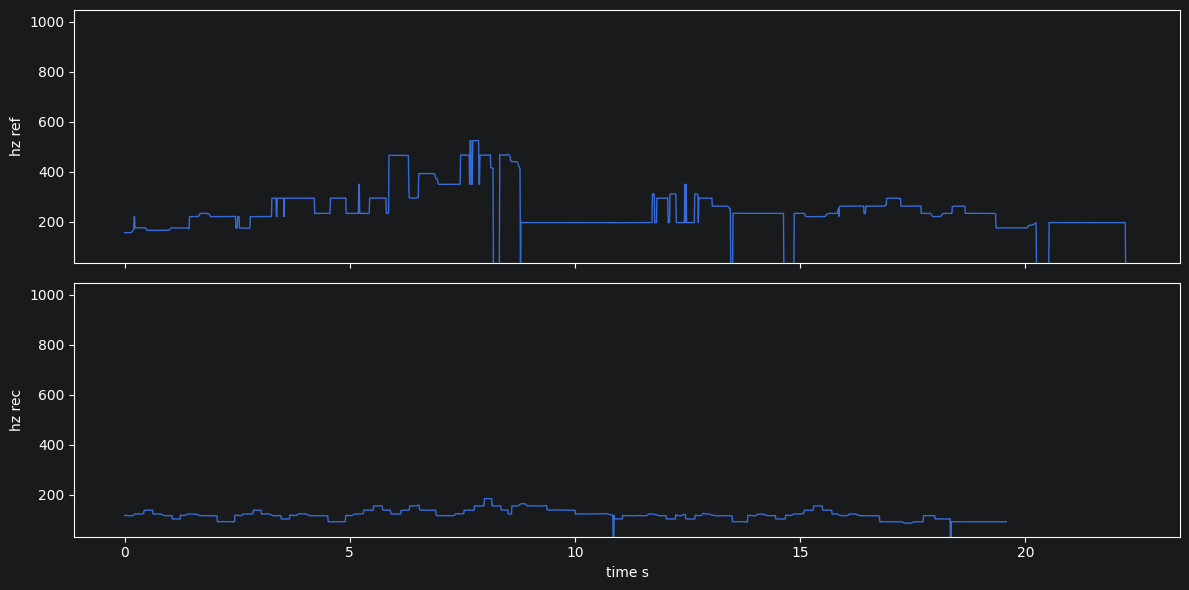

{
  "Pitch Score": 0,
  "Octave Score": 23,
  "Timing Score": 25,
  "Timing Reliable": false,
  "Overall": 17,
  "Median Cents": 1198.4855532528109,
  "Median Octave": 167.7197706005844,
  "Mean Cents": 1185.8829375930477,
  "Median Onset (ms)": 69.99969482421875,
  "Mean Onset (ms)": 152.82049953428088,
  "Tempo Ref": 127.65957446808511,
  "Tempo Rec": 146.34146341463415,
  "Issues": [
    "Octave low: 23/100 | Median: 168 cents",
    "Timing unreliable: tempo 128 vs 146 bpm | onset 86 vs 107",
    "Tempo mismatch: ref 128 vs rec 146 bpm"
  ],
  "Voiced Frames": 2262,
  "Onsets Ref": 86,
  "Onsets Rec": 107
}


In [25]:
def plot_practice(ref_path, rec_path):
    rep, ref_dat, rec_dat = practice_report(ref_path, rec_path)
    tr, hr, cr = ref_dat
    tp, hp, cp = rec_dat

    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    ax[0].plot(tr, hr, linewidth=1)
    ax[0].set_ylabel("hz ref")
    ax[0].set_ylim(fmin, fmax)

    ax[1].plot(tp, hp, linewidth=1)
    ax[1].set_ylabel("hz rec")
    ax[1].set_xlabel("time s")
    ax[1].set_ylim(fmin, fmax)

    plt.tight_layout()
    plt.show()
    print(js.dumps(rep, indent=2))


if len(ref_demo) >= 2:
    plot_practice(ref_demo[0], ref_demo[1])
